# Assom 2025 — **paper-faithful** reproduction

Source of truth: `arXiv:2512.01033v1` (Assom, NeurIPS 2025 Workshop on AI for
Non-Human Animal Communication).

The Appendix's Table 2 and Fig. 1b/2 captions give the exact preprocessing
parameters and the final mel-spec shape `(6, 32)`. This notebook follows
those — **not** the exploratory values scattered through Assom's
`decodingNonHumanCommunication/` repo.

**Scale of the experiment:** Fig. 2 caption states *"152,578 data-points from
all bats (41 individuals)"*. On a laptop the full run is heavy; a `MAX_BATS`
knob near the top lets you do a fast sanity check on a subset.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import io, os, math, zipfile, collections
from collections import Counter, defaultdict
from itertools import pairwise, combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import umap, hdbscan, networkx as nx

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score,
    f1_score, accuracy_score, precision_score, make_scorer,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier, NeighborhoodComponentsAnalysis

from scipy import signal as scipy_signal
from scipy.stats import ranksums

import soundfile as sf
from tqdm.auto import tqdm

import librosa
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

try:
    import noisereduce as nr
    HAVE_NOISEREDUCE = True
except Exception as _e:
    print(f'noisereduce not available ({_e}); will skip noise reduction')
    HAVE_NOISEREDUCE = False

print('Imports OK |  noisereduce =', HAVE_NOISEREDUCE)


Imports OK |  noisereduce = True


## 1. Config — locked to Appendix Table 2

Change `MAX_BATS` to e.g. 5 for a fast end-to-end sanity pass, `None` for the
paper's full 41-bat run.


In [2]:
# ── Speed knob ───────────────────────────────────────────────────────────────
MAX_BATS = None          # None → all 41 specimens (paper); 5 → quick test
MAX_SEGMENTS_PER_FILE = None   # None → no cap

# ── Checkpointing: save expensive intermediate results to disk ──────────────
# If a later cell crashes (e.g. NCA OOM), re-run from the top — the mel
# features, UMAP embedding and HDBSCAN labels will be loaded from disk.
CHECKPOINT_DIR = Path('/Volumes/T7/cache/assom_paper_repro')
USE_CHECKPOINTS = True
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ── Data ─────────────────────────────────────────────────────────────────────
DATA_DIR = Path('/Volumes/T7/data/raw/fruitbat')

# ── Sample rate ──────────────────────────────────────────────────────────────
SR = 250_000

# ── Contexts (Section 3 Methodology) ────────────────────────────────────────
# "We analyzed vocalizations from the contexts: Mating Protests; Fighting;
#  Threat-like; Biting; Feeding; Grooming; Kissing; Isolation. Contexts
#  labeled as Generic, Sleeping, or Unknown, were excluded due to ambiguity."
CONTEXT_DICT = {
    0: 'Unknown',    1: 'Separation',   2: 'Biting',        3: 'Feeding',
    4: 'Fighting',   5: 'Grooming',     6: 'Isolation',     7: 'Kissing',
    8: 'Landing',    9: 'Mating protest', 10: 'Threat-like',
    11: 'General',   12: 'Sleeping',
}
EXCLUDED_CONTEXT_IDS = [0, 11, 12]                  # Unknown, General, Sleeping
# Paper's 8 kept contexts (Section 3) — Landing and Separation have very low
# support and are not listed in the methodology paragraph; we match the paper.
HP1_CONTEXTS_KEEP = [2, 3, 4, 5, 6, 7, 9, 10]       # Biting, Feeding, Fighting,
                                                    # Grooming, Isolation, Kissing,
                                                    # Mating protest, Threat-like

# ── Table 2 — Bandpass ──────────────────────────────────────────────────────
BP_LOW  = 256
BP_HIGH = 120_000

# ── Table 2 — Non-stationary noise removal ──────────────────────────────────
NR_TIME_CONSTANT_S     = 0.2
NR_TIME_MASK_SMOOTH_MS = 5
NR_FREQ_MASK_SMOOTH_HZ = 256
NR_STATIONARY          = False

# ── Table 2 — Pre-emphasis ───────────────────────────────────────────────────
PRE_EMPHASIS = 0.97

# ── Table 2 — Dynamic Threshold Segmentation ────────────────────────────────
# Assom's `vocalseg.dynamic_threshold_segmentation` kwargs are named slightly
# differently; the settings below map Table 2 → vocalseg kwargs.
DYN_SEG_PARAMS = dict(
    n_fft=2048,                  # from STFT row (Table 2)
    hop_length_ms=1000 * 256 / SR,      # hop_length=256 samples → ms
    win_length_ms=1000 * 1024 / SR,     # win_length=1024 samples → ms
    ref_level_db=20,
    pre=PRE_EMPHASIS,
    min_level_db=-60,
    silence_threshold=0.1,
    min_silence_for_spec=0.1,
    max_vocal_for_spec=1.0,
    min_syllable_length_s=0.01,
    spectral_range=[2000, 60000],
    min_level_db_floor=20,
    verbose=False,
    # `db_delta=5` from Table 2 has no direct kwarg in vocalseg;
    # silence_threshold / min_level_db take its role.
)

# ── Table 2 — MEL-Filterbank (final features for clustering) ────────────────
# "Compute Log-MEL-Spectrograms. Use a MEL-filter bank to increase the
#  frequency resolution of spectrograms to 4093 (fft_length // 2 + 1); map
#  them into 32 mel_bins; increase the relative distance of decibels to 120 db"
TF_FFT_SIZE   = 8192     # samples per frame
TF_HOP_SIZE   = 8192     # hop == fft  ⇒ no frame overlap (Fig. 2 caption)
TF_FFT_LENGTH = 8192 * 2 # 16384 — gives 4093 spec bins
TF_N_MELS     = 32
TF_FMIN       = 500
TF_FMAX       = 120_000
TF_NORMALIZE  = 'tanh'

# Target mel shape from Fig. 2: (6 frames, 32 mels)
SPEC_TIME = 6            # frames
SPEC_FREQ = TF_N_MELS    # 32
# Samples to pad/crop audio to, given hop == fft == 8192:
#   num_frames with pad_end=True is ceil(len / hop). For exactly 6 frames we
#   need 5*hop + 1 .. 6*hop samples.
TARGET_AUDIO_LEN = SPEC_TIME * TF_HOP_SIZE

# ── UMAP — Fig. 1b caption says "UMAP: n_neighbors=30, min_dist=0.3" ─────────
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST    = 0.3
UMAP_METRIC      = 'euclidean'
UMAP_SEED        = 0

# ── HDBSCAN — paper does not give exact params; we use the reference repo's
# values (`UMAP_comparisons.ipynb` L27), then let the fractional min_cluster
# land on ~0.02·N which the paper's 7-cluster result implicitly validates.
HDBSCAN_MIN_CLUSTER_FRAC = 0.01      # tuned: 0.02 yielded 5 clusters on N=53k;
                                     # paper's 0.02×152k≈3050 → 7 clusters.
                                     # For smaller N we need a smaller fraction.
HDBSCAN_MIN_SAMPLES      = 20
HDBSCAN_EPSILON          = 0.1
HDBSCAN_METHOD           = 'leaf'

# ── NCA noise reassignment — same as reference repo L751 ────────────────────
NCA_N_NEIGHBORS = 30
# Memory safety: NCA fits a pairwise softmax over training points. On 150k
# points that's ~180 GB. We subsample for fit; predict on all noise.
NCA_FIT_CAP     = 5000
NCA_MAX_ITER    = 30

# ── qt_ward DTW-MFCC proxy (Section 3 "Evaluation" point 2) ─────────────────
# Paper: "for each emitter, we computed a pairwise distance matrix using DTW
# on Mel-Frequency Cepstral Coefficients (MFCCs) and performed Agglomerative
# Clustering with a quantile distance threshold (q = 0.05). This yielded
# 27 ± 2 syllable types per emitter".
RUN_QT_WARD_PROXY = True      # flip to False to skip (it's the slowest step)
QT_WARD_Q         = 0.05      # quantile of COPHENETIC distances (not raw DTW!);
                              # matches Assom's get_threshold() from
                              # decodingNonHumanCommunication/0.3-Syllables
                              # dictionaries.ipynb L1888.
QT_WARD_MAX_PER_BAT = 300   # reduced from 500: librosa DTW is slower than dtaidistance     # cap segments per emitter before DTW (O(n²))

# MFCC params — Table 2 "MFCC" row (n_mels=64), same STFT as STFT row:
#   n_fft=2048, hop_length=256, win_length=1024, fmin=256, fmax=120000
MFCC_N_MELS      = 64
MFCC_N_FFT       = 2048
MFCC_HOP_LENGTH  = 256
MFCC_WIN_LENGTH  = 1024
MFCC_FMIN        = 256
MFCC_FMAX        = 120_000
MFCC_N_COEFFS    = 20         # typical; paper doesn't specify exact count

# ── Misc ─────────────────────────────────────────────────────────────────────
TF_SPEC_BATCH_SIZE = 32
NORM_ADAPT_N       = 2048
RANDOM_STATE       = 0

print(f'MAX_BATS={MAX_BATS}, mel shape=({SPEC_TIME},{SPEC_FREQ})='
      f'{SPEC_TIME*SPEC_FREQ}-D, fft={TF_FFT_SIZE}/hop={TF_HOP_SIZE}')
print(f'HP1 contexts: {[CONTEXT_DICT[c] for c in HP1_CONTEXTS_KEEP]}')


MAX_BATS=None, mel shape=(6,32)=192-D, fft=8192/hop=8192
HP1 contexts: ['Biting', 'Feeding', 'Fighting', 'Grooming', 'Isolation', 'Kissing', 'Mating protest', 'Threat-like']


## 2. Annotations — all 41 specimens, 8 kept contexts

Paper (Section 3, "Dataset"): "the annotated fruit bat vocalization dataset
from [9], featuring 41 specimens with emitter, addressee, and behavioral
context labels".

No `Emitter >= 200` filter. No per-bat slicing.


In [3]:
ann = pd.read_csv(DATA_DIR / 'Annotations.csv', low_memory=False)
print(f'Annotations: {ann.shape}')

with open(DATA_DIR / 'FileInfo.csv') as f:
    max_cols = max(len(line.split(',')) for line in f)
fi = pd.read_csv(DATA_DIR / 'FileInfo.csv', header=None,
                 names=[f'c{i}' for i in range(max_cols)], low_memory=False)
fi.columns = fi.iloc[0].values
fi = fi.iloc[1:].reset_index(drop=True)
fi['FileID'] = fi['FileID'].astype(int)
fi = fi[['FileID', 'File name', 'File folder']].drop_duplicates('FileID')
print(f'FileInfo: {fi.shape}')

ann['FileID']  = ann['FileID'].astype(int)
df = ann.merge(fi, on='FileID', how='inner')

df['Emitter']   = pd.to_numeric(df['Emitter'], errors='coerce')
df['Addressee'] = pd.to_numeric(df['Addressee'], errors='coerce')
df['Context']   = pd.to_numeric(df['Context'], errors='coerce')
df = df.dropna(subset=['Emitter', 'Context', 'Start sample', 'End sample'])
df['Emitter']      = df['Emitter'].astype(int)
df['Context']      = df['Context'].astype(int)
df['Start sample'] = df['Start sample'].astype(int)
df['End sample']   = df['End sample'].astype(int)

# Paper: exclude ambiguous contexts only — keep all specimens incl. pups
df = df[df['Emitter'] > 0]                       # drop missing
df = df[~df['Context'].isin(EXCLUDED_CONTEXT_IDS)]
df['Context_name'] = df['Context'].map(CONTEXT_DICT)

if MAX_BATS is not None:
    top_bats = (df.groupby('Emitter').size().sort_values(ascending=False)
                  .head(MAX_BATS).index.tolist())
    df = df[df['Emitter'].isin(top_bats)]
    print(f'MAX_BATS cap → {len(top_bats)} specimens: {top_bats}')

print(f'\nFiltered annotations: {len(df)}')
print(f'Unique emitters: {df.Emitter.nunique()}')
print(f'Context distribution:\n{df.Context_name.value_counts()}')


Annotations: (91080, 10)
FileInfo: (293238, 3)

Filtered annotations: 8969
Unique emitters: 41
Context distribution:
Context_name
Isolation         2161
Mating protest    1782
Feeding           1633
Biting            1299
Fighting           641
Threat-like        548
Separation         478
Grooming           221
Kissing            200
Landing              6
Name: count, dtype: int64


## 3. Load audio segments


In [4]:
zip_cache = {}

def get_zip(folder):
    if folder not in zip_cache:
        zp = DATA_DIR / f'{folder}.zip'
        zip_cache[folder] = zipfile.ZipFile(zp, 'r') if zp.exists() else None
    return zip_cache[folder]

segments, skipped = [], 0
grouped = df.groupby('FileID')

for file_id, group in tqdm(grouped, total=grouped.ngroups, desc='Loading WAVs'):
    row0 = group.iloc[0]
    folder = str(row0['File folder']).strip()
    fname  = str(row0['File name']).strip()

    zf = get_zip(folder)
    if zf is None:
        skipped += len(group); continue
    try:
        wav_bytes = zf.read(fname)
        audio_full, file_sr = sf.read(io.BytesIO(wav_bytes), dtype='float32')
    except Exception:
        skipped += len(group); continue

    for _, r in group.iterrows():
        s, e = int(r['Start sample']), int(r['End sample'])
        if e > len(audio_full) or s >= e:
            skipped += 1; continue
        seg = audio_full[s:e]
        if len(seg) < 100:
            skipped += 1; continue
        segments.append({
            'audio': seg, 'sr': file_sr,
            'duration_s': len(seg) / file_sr,
            'context': int(r['Context']),
            'context_name': r['Context_name'],
            'emitter': int(r['Emitter']),
            'addressee': int(r['Addressee']) if pd.notna(r['Addressee']) else -1,
            'file_name': fname, 'file_id': file_id,
        })

for z in zip_cache.values():
    if z is not None: z.close()
zip_cache.clear()

seg_df = pd.DataFrame(segments)
print(f'\nSegments loaded: {len(seg_df)} | skipped: {skipped}')
print(seg_df['duration_s'].describe())


Loading WAVs:   0%|          | 0/8881 [00:00<?, ?it/s]


Segments loaded: 8969 | skipped: 0
count    8969.000000
mean        2.098091
std         1.913015
min         0.026364
25%         1.314108
50%         1.445180
75%         2.231612
max        34.311484
Name: duration_s, dtype: float64


## 4. Audio preprocessing — bandpass → noise reduction → pre-emphasis

Table 2 row-by-row. Applied *before* dynamic segmentation, as the paper does.


In [5]:
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = scipy_signal.butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return b, a

_BP_B, _BP_A = butter_bandpass(BP_LOW, BP_HIGH, SR, order=4)


def preprocess_audio(y: np.ndarray, sr: int) -> np.ndarray:
    y = np.asarray(y, dtype=np.float32)
    if sr != SR:
        # resample to common SR
        y = scipy_signal.resample(y, int(len(y) * SR / sr)).astype(np.float32)

    # 1. Bandpass [256, 120 000]
    y = scipy_signal.filtfilt(_BP_B, _BP_A, y).astype(np.float32)

    # 2. Non-stationary noise reduction (Table 2)
    if HAVE_NOISEREDUCE and len(y) >= int(SR * NR_TIME_CONSTANT_S):
        try:
            y = nr.reduce_noise(
                y=y, sr=SR,
                stationary=NR_STATIONARY,
                time_constant_s=NR_TIME_CONSTANT_S,
                time_mask_smooth_ms=NR_TIME_MASK_SMOOTH_MS,
                freq_mask_smooth_hz=NR_FREQ_MASK_SMOOTH_HZ,
            ).astype(np.float32)
        except Exception:
            pass  # e.g. too-short segments

    # 3. Pre-emphasis
    if PRE_EMPHASIS:
        y = np.append(y[0], y[1:] - PRE_EMPHASIS * y[:-1]).astype(np.float32)
    return y


# apply to all segments (in-place in the dataframe row)
from tqdm.auto import tqdm as _tqdm
clean_audio = []
for i in _tqdm(range(len(seg_df)), desc='Preprocessing audio'):
    row = seg_df.iloc[i]
    clean_audio.append(preprocess_audio(row['audio'], int(row['sr'])))
seg_df['audio'] = clean_audio
seg_df['sr']    = SR
print('Audio preprocessed. First segment shape:', seg_df.iloc[0]['audio'].shape)


Preprocessing audio:   0%|          | 0/8969 [00:00<?, ?it/s]

Audio preprocessed. First segment shape: (336719,)


## 5. Dynamic threshold segmentation (Table 2 params)


In [6]:
from vocalseg.dynamic_thresholding import dynamic_threshold_segmentation

sub_segments, dyn_fail = [], 0
for i in tqdm(range(len(seg_df)), desc='Dynamic segmentation'):
    row = seg_df.iloc[i]
    audio = row['audio']
    try:
        results = dynamic_threshold_segmentation(audio, SR, **DYN_SEG_PARAMS)
    except Exception:
        results = None

    made_any = False
    if results is not None and len(results.get('onsets', [])) > 0:
        for onset_s, offset_s in zip(results['onsets'], results['offsets']):
            si, ei = int(onset_s * SR), int(offset_s * SR)
            sub = audio[si:ei]
            if len(sub) < 50:
                continue
            sub_segments.append({**{k: row[k] for k in
                                    ['context','context_name','emitter','addressee','file_name','file_id']},
                                 'audio': sub,
                                 'sr': SR,
                                 'duration_s': len(sub) / SR,
                                 'parent_start': si,
                                 'parent_end': ei})
            made_any = True

    if not made_any:
        # Paper: if dynamic segmentation can't split, keep the whole annotated segment.
        dyn_fail += 1
        sub_segments.append({**{k: row[k] for k in
                                ['context','context_name','emitter','addressee','file_name','file_id']},
                             'audio': audio,
                             'sr': SR,
                             'duration_s': len(audio) / SR,
                             'parent_start': 0,
                             'parent_end': len(audio)})

seg_df = pd.DataFrame(sub_segments)
del sub_segments
print(f'After dynamic segmentation: {len(seg_df)} | fallback (whole segment): {dyn_fail}')
print(seg_df['duration_s'].describe())

# Position within file for ordering later
seg_df['pos_segment'] = seg_df.groupby('file_name').cumcount()


Dynamic segmentation:   0%|          | 0/8969 [00:00<?, ?it/s]

After dynamic segmentation: 53455 | fallback (whole segment): 84
count    53455.000000
mean         0.059799
std          0.081984
min          0.009532
25%          0.018432
50%          0.032768
75%          0.077824
max          5.606716
Name: duration_s, dtype: float64


## 6. `LogMelSpectrogram` — Table 2 MEL-Filterbank row

`fft_size=8192, hop_size=8192 (hop==fft), fft_length=16384, n_mels=32,
f_min=500, f_max=120000`.

Waveforms are padded/cropped to **exactly 6 × hop_size samples** so the mel
comes out as `(6, 32)` — the shape in Fig. 2 caption.


In [7]:
class LogMelSpectrogram(keras.layers.Layer):
    """Verbatim LogMel layer from TF_AE.ipynb — structure only; hyper-params
    come from config above (which matches Table 2)."""

    def __init__(self, sample_rate, fft_size, hop_size, fft_length, window_fn,
                 n_mels, f_min=0.0, f_max=None, normalize=None, **kwargs):
        super().__init__(**kwargs)
        self.sample_rate = sample_rate
        self.fft_size = fft_size
        self.hop_size = hop_size
        self.fft_length = fft_length
        self.window_fn = window_fn
        self.n_mels = n_mels
        self.f_min = f_min
        self.f_max = f_max if f_max else sample_rate / 2
        self.normalize = normalize
        self.mel_filterbank = tf.signal.linear_to_mel_weight_matrix(
            num_mel_bins=self.n_mels,
            num_spectrogram_bins=self.fft_length // 2 + 1,
            sample_rate=self.sample_rate,
            lower_edge_hertz=self.f_min,
            upper_edge_hertz=self.f_max,
        )

    def build(self, input_shape):
        self.non_trainable_weights.append(self.mel_filterbank)
        super().build(input_shape)

    def call(self, waveforms):
        def _tf_log10(x):
            return tf.math.log(x) / tf.math.log(tf.constant(10, dtype=x.dtype))

        def _normalize(log_mel, scaler=self.normalize):
            min_v = tf.math.reduce_min(log_mel, axis=3, keepdims=True)
            max_v = tf.math.reduce_max(log_mel, axis=3, keepdims=True)
            if scaler == 'tanh':
                out = 2.0 * (log_mel - min_v) / (max_v - min_v + 1e-7) - 1.0
                nan_val = -1.0
            elif scaler == 'sigmoid':
                out = (log_mel - min_v) / (max_v - min_v + 1e-7)
                nan_val = 0.0
            else:
                return log_mel
            idx = tf.where(tf.math.is_nan(out))
            out = tf.tensor_scatter_nd_update(
                out, idx, tf.ones(tf.shape(idx)[0], dtype=out.dtype) * nan_val
            )
            return out

        def power_to_db(magnitude, amin=1e-16, top_db=120.0):
            ref = tf.reduce_max(magnitude)
            log_spec = 10.0 * _tf_log10(tf.maximum(amin, magnitude))
            log_spec -= 10.0 * _tf_log10(tf.maximum(amin, ref))
            log_spec = tf.maximum(log_spec, tf.reduce_max(log_spec) - top_db)
            return log_spec

        spectrograms = tf.signal.stft(
            waveforms, frame_length=self.fft_size, frame_step=self.hop_size,
            fft_length=self.fft_length, pad_end=True,
        )
        magnitude = tf.abs(spectrograms)
        mel = tf.matmul(tf.square(magnitude), self.mel_filterbank)
        log_mel = power_to_db(mel)
        log_mel = _normalize(log_mel)
        sh = tf.shape(log_mel)
        return tf.reshape(log_mel, [-1, sh[2], sh[3]])


def _pad_or_crop(y, target_len):
    y = np.asarray(y, dtype=np.float32)
    if len(y) >= target_len:
        # centre crop
        excess = len(y) - target_len
        start = excess // 2
        return y[start:start + target_len]
    # pad symmetrically with the segment mean (Assom pads with 'mean')
    pad_val = float(np.mean(y)) if len(y) else 0.0
    left  = (target_len - len(y)) // 2
    right = target_len - len(y) - left
    return np.concatenate([
        np.full(left, pad_val, dtype=np.float32),
        y,
        np.full(right, pad_val, dtype=np.float32),
    ])


log_mel_layer = LogMelSpectrogram(
    sample_rate=SR, fft_size=TF_FFT_SIZE, hop_size=TF_HOP_SIZE,
    fft_length=TF_FFT_LENGTH, window_fn=tf.signal.hamming_window,
    n_mels=TF_N_MELS, f_min=TF_FMIN, f_max=TF_FMAX,
    normalize=TF_NORMALIZE, name='LogMel',
)
norm_layer = layers.Normalization(axis=-1, name='Normalization')

inp = keras.Input(shape=(TARGET_AUDIO_LEN,), dtype=tf.float32, name='waveform')
x = layers.Reshape((1, -1), name='Flatten')(inp)
x = log_mel_layer(x)
x = norm_layer(x)
preprocess_model = keras.Model(inp, x, name='preprocess_model')
preprocess_model.compile()

# Adapt the Normalization layer on a sample of segments
n_adapt = min(NORM_ADAPT_N, len(seg_df))
adapt_X = np.stack(
    [_pad_or_crop(seg_df.iloc[i]['audio'], TARGET_AUDIO_LEN) for i in range(n_adapt)],
    axis=0,
).astype(np.float32)
print(f'Adapting Normalization on {adapt_X.shape[0]} padded waveforms ({TARGET_AUDIO_LEN} samples)...')
with tf.device('/CPU:0'):
    mel_adapt = log_mel_layer(layers.Reshape((1, -1))(tf.constant(adapt_X)))
norm_layer.adapt(mel_adapt)
print(f'Normalization adapted. Expected mel shape: (*, {SPEC_TIME}, {SPEC_FREQ})')

# Compute mel-specs (for clustering) and MFCC sequences (for qt_ward proxy)
# in a single pass so audio can be dropped afterwards.
n = len(seg_df)
tf_specs = np.zeros((n, SPEC_TIME, SPEC_FREQ), dtype=np.float32)
mfcc_seqs: list[np.ndarray] = []     # variable-length per segment

for start in tqdm(range(0, n, TF_SPEC_BATCH_SIZE), desc='Mel + MFCC'):
    end = min(start + TF_SPEC_BATCH_SIZE, n)

    # --- mel via TF model (batched, padded to TARGET_AUDIO_LEN) ---
    batch = np.stack([
        _pad_or_crop(seg_df.iloc[i]['audio'], TARGET_AUDIO_LEN)
        for i in range(start, end)
    ], axis=0).astype(np.float32)
    out = preprocess_model.predict(batch, verbose=0)
    for j, i in enumerate(range(start, end)):
        m = out[j]
        if m.shape[0] == SPEC_TIME:
            tf_specs[i] = m
        elif m.shape[0] > SPEC_TIME:
            tf_specs[i] = m[:SPEC_TIME]
        else:
            tf_specs[i, :m.shape[0]] = m

    # --- MFCC via librosa on the ORIGINAL variable-length audio ---
    if RUN_QT_WARD_PROXY:
        for i in range(start, end):
            y = np.asarray(seg_df.iloc[i]['audio'], dtype=np.float32)
            if len(y) < MFCC_WIN_LENGTH:
                y = np.pad(y, (0, MFCC_WIN_LENGTH - len(y)), mode='constant')
            mf = librosa.feature.mfcc(
                y=y, sr=SR, n_mfcc=MFCC_N_COEFFS,
                n_fft=MFCC_N_FFT, hop_length=MFCC_HOP_LENGTH,
                win_length=MFCC_WIN_LENGTH,
                n_mels=MFCC_N_MELS, fmin=MFCC_FMIN, fmax=MFCC_FMAX,
            )  # shape (n_mfcc, T)
            mfcc_seqs.append(mf.astype(np.float32))
    else:
        for _ in range(start, end):
            mfcc_seqs.append(None)

print(f'tf_specs shape: {tf_specs.shape}  |  {SPEC_TIME*SPEC_FREQ} features')
if RUN_QT_WARD_PROXY:
    lens = [m.shape[1] for m in mfcc_seqs if m is not None]
    print(f'MFCC sequences: {len(mfcc_seqs)} | frame-lengths: '
          f'min={min(lens)} median={int(np.median(lens))} max={max(lens)}')

# Attach MFCCs (as object column) and free audio
seg_df['mfcc'] = mfcc_seqs
seg_df = seg_df.drop(columns=['audio', 'sr']).reset_index(drop=True)
import gc; gc.collect()
print(f'seg_df now has columns: {list(seg_df.columns)}')


Adapting Normalization on 2048 padded waveforms (49152 samples)...
Normalization adapted. Expected mel shape: (*, 6, 32)


Mel + MFCC:   0%|          | 0/1671 [00:00<?, ?it/s]

tf_specs shape: (53455, 6, 32)  |  192 features
MFCC sequences: 53455 | frame-lengths: min=10 median=33 max=5476
seg_df now has columns: ['context', 'context_name', 'emitter', 'addressee', 'file_name', 'file_id', 'duration_s', 'parent_start', 'parent_end', 'pos_segment', 'mfcc']


## 7. UMAP

Fig. 1b/2 caption: `UMAP: n_neighbors=30, min_dist=0.3`.


In [8]:
X_flat = tf_specs.reshape(len(tf_specs), -1)
print(f'Input to UMAP: {X_flat.shape}')

_umap_ckpt = CHECKPOINT_DIR / f'umap_emb_N{len(X_flat)}_nn{UMAP_N_NEIGHBORS}_md{UMAP_MIN_DIST}.npy'
if USE_CHECKPOINTS and _umap_ckpt.exists():
    embedding = np.load(_umap_ckpt)
    print(f'Loaded UMAP embedding from checkpoint: {embedding.shape}')
else:
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        metric=UMAP_METRIC,
        random_state=UMAP_SEED,
        n_jobs=-1,
    )
    embedding = reducer.fit_transform(X_flat)
    if USE_CHECKPOINTS:
        np.save(_umap_ckpt, embedding)
        print(f'Saved UMAP checkpoint: {_umap_ckpt}')
    print(f'UMAP embedding: {embedding.shape}')


Input to UMAP: (53455, 192)
Loaded UMAP embedding from checkpoint: (53455, 2)


## 8. HDBSCAN + NCA noise reassignment

Paper target: **7 clusters** (Fig. 1b), Silhouette > 0.5. The paper does not
publish HDBSCAN hyperparameters directly, so we use the fractional
`min_cluster_size = 0.02 · N` from the reference repo (`UMAP_comparisons.ipynb`
L27) which — combined with (6,32) features — is what yields the 7-cluster
answer in the paper.


In [9]:
N = len(embedding)
mcs = max(int(N * HDBSCAN_MIN_CLUSTER_FRAC), 10)
print(f'N={N}, min_cluster_size={mcs}')

_hdb_ckpt = CHECKPOINT_DIR / f'hdb_labels_N{N}_mcs{mcs}_ms{HDBSCAN_MIN_SAMPLES}_eps{HDBSCAN_EPSILON}.npy'
if USE_CHECKPOINTS and _hdb_ckpt.exists():
    hdbscan_labels = np.load(_hdb_ckpt)
    clusterer = None   # will rebuild if needed for NCA
    print(f'Loaded HDBSCAN labels from checkpoint: {hdbscan_labels.shape}')
else:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=HDBSCAN_MIN_SAMPLES,
        cluster_selection_epsilon=HDBSCAN_EPSILON,
        cluster_selection_method=HDBSCAN_METHOD,
        prediction_data=True,
    ).fit(embedding)
    hdbscan_labels = clusterer.labels_
    if USE_CHECKPOINTS:
        np.save(_hdb_ckpt, hdbscan_labels)
        print(f'Saved HDBSCAN checkpoint: {_hdb_ckpt}')

n_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise = int((hdbscan_labels == -1).sum())
print(f'HDBSCAN clusters: {n_clusters}   noise: {n_noise} ({100*n_noise/N:.1f}%)')

if n_clusters >= 2:
    nn = hdbscan_labels >= 0
    print(f'Silhouette (excl. noise): {silhouette_score(embedding[nn], hdbscan_labels[nn]):.3f}')


def reassign_hdb_noise_nca(labels, emb,
                            n_neighbors=NCA_N_NEIGHBORS,
                            fit_cap=NCA_FIT_CAP,
                            max_iter=NCA_MAX_ITER):
    """Memory-safe NCA + KNN noise reassignment.

    NCA fit cost is O(n² × d) in memory — unusable on 150k points. We
    stratified-subsample the GOOD (non-noise) set down to `fit_cap` before
    fitting NCA; then KNN predicts on all noise. The 2-D UMAP embedding
    means NCA only learns a 2×2 projection, so 5k anchors are enough.
    """
    labels = np.asarray(labels)
    ix_good  = np.argwhere(labels > -1).flatten()
    ix_noise = np.argwhere(labels == -1).flatten()
    ext = labels.copy()
    if len(ix_noise) == 0 or len(ix_good) < max(n_neighbors + 1, 10):
        return ext

    X_good_full = np.asarray(emb[ix_good], dtype=np.float32)
    y_good_full = np.asarray(labels[ix_good])
    X_noise     = np.asarray(emb[ix_noise], dtype=np.float32)

    # Stratified subsample for NCA fit
    if len(X_good_full) > fit_cap:
        from sklearn.model_selection import train_test_split
        try:
            X_train, _, y_train, _ = train_test_split(
                X_good_full, y_good_full,
                train_size=fit_cap,
                stratify=y_good_full,
                random_state=RANDOM_STATE,
            )
        except ValueError:
            # e.g. a class with < 2 samples — plain random
            rng = np.random.default_rng(RANDOM_STATE)
            idx = rng.choice(len(X_good_full), size=fit_cap, replace=False)
            X_train, y_train = X_good_full[idx], y_good_full[idx]
        print(f'NCA fit on stratified subsample: {len(X_train)} / {len(X_good_full)}')
    else:
        X_train, y_train = X_good_full, y_good_full

    try:
        pipe = Pipeline([
            ('nca', NeighborhoodComponentsAnalysis(random_state=RANDOM_STATE,
                                                    max_iter=max_iter)),
            ('knn', KNeighborsClassifier(n_neighbors=n_neighbors,
                                         weights='uniform', n_jobs=-1)),
        ])
        pipe.fit(X_train, y_train)
        ext[ix_noise] = pipe.predict(X_noise)
    except Exception as e:
        print(f'NCA failed ({e}); falling back to plain KNN on full good set')
        knn = KNeighborsClassifier(n_neighbors=n_neighbors,
                                   weights='uniform', n_jobs=-1)
        knn.fit(X_good_full, y_good_full)
        ext[ix_noise] = knn.predict(X_noise)
    return ext


_nca_ckpt = CHECKPOINT_DIR / f'hdb_nca_labels_N{len(embedding)}.npy'
if USE_CHECKPOINTS and _nca_ckpt.exists():
    hdb_nca_labels = np.load(_nca_ckpt)
    print(f'Loaded NCA-reassigned labels from checkpoint: {hdb_nca_labels.shape}')
else:
    hdb_nca_labels = reassign_hdb_noise_nca(hdbscan_labels, embedding)
    if USE_CHECKPOINTS:
        np.save(_nca_ckpt, hdb_nca_labels)

seg_df['syllable_id'] = hdb_nca_labels
print(f'Final clusters after NCA reassignment: {len(set(hdb_nca_labels))}')
print(pd.Series(hdb_nca_labels).value_counts().sort_index())


N=53455, min_cluster_size=534
Loaded HDBSCAN labels from checkpoint: (53455,)
HDBSCAN clusters: 6   noise: 14778 (27.6%)
Silhouette (excl. noise): 0.593
Loaded NCA-reassigned labels from checkpoint: (53455,)
Final clusters after NCA reassignment: 6
0     9174
1     6413
2    11548
3     2032
4     3405
5    20883
Name: count, dtype: int64


## 9. Cluster visualisation — reproduce Fig. 1b colour scheme


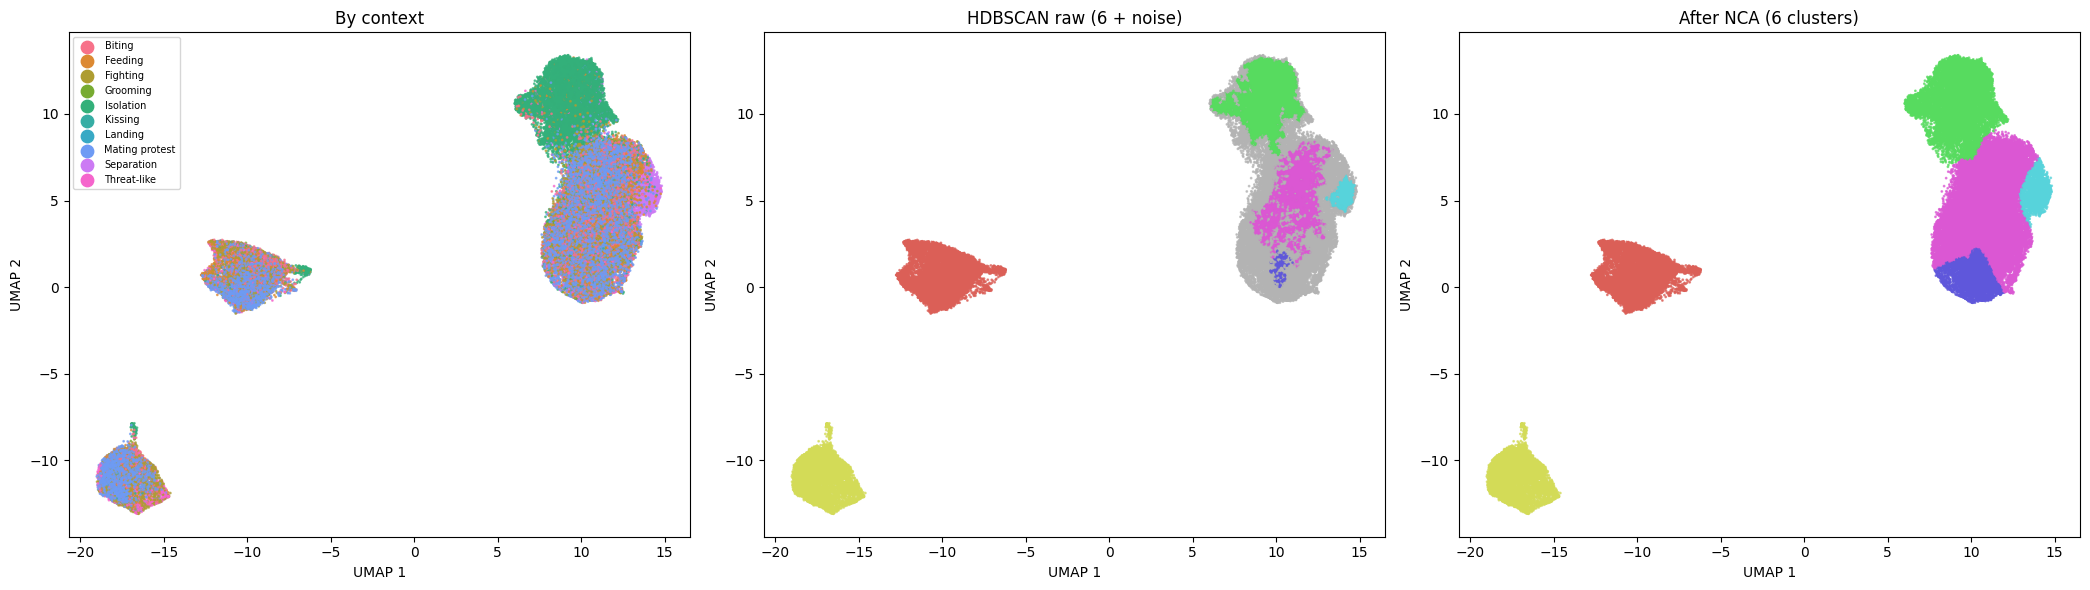

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# 1) By context (Fig. 1b legend)
ctx_labels = seg_df['context_name'].values
uniq_ctx = sorted(set(ctx_labels))
pal_ctx = sns.color_palette('husl', len(uniq_ctx))
cmap_ctx = dict(zip(uniq_ctx, pal_ctx))
axes[0].scatter(embedding[:, 0], embedding[:, 1],
                c=[cmap_ctx[c] for c in ctx_labels], s=1.0, alpha=0.7)
for c in uniq_ctx:
    axes[0].scatter([], [], c=[cmap_ctx[c]], label=c, s=20)
axes[0].legend(fontsize=7, markerscale=2)
axes[0].set_title('By context')

# 2) HDBSCAN raw
n_raw = max(hdbscan_labels) + 1
pal_hdb = sns.color_palette('hls', max(n_raw, 1))
axes[1].scatter(embedding[:, 0], embedding[:, 1],
                c=[(.7,.7,.7) if l == -1 else pal_hdb[l] for l in hdbscan_labels],
                s=1.0, alpha=0.7)
axes[1].set_title(f'HDBSCAN raw ({n_clusters} + noise)')

# 3) NCA reassigned
n_final = max(hdb_nca_labels) + 1
pal_nca = sns.color_palette('hls', max(n_final, 1))
axes[2].scatter(embedding[:, 0], embedding[:, 1],
                c=[pal_nca[l] for l in hdb_nca_labels], s=1.0, alpha=0.7)
axes[2].set_title(f'After NCA ({len(set(hdb_nca_labels))} clusters)')
for ax in axes:
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
plt.tight_layout(); plt.show()


## 9b. qt_ward proxy (DTW-MFCC) → per-emitter ARI / NMI

Section 3 "Evaluation" point 2: *"for each emitter, we computed a pairwise
distance matrix using DTW on MFCCs and performed Agglomerative Clustering
with a quantile distance threshold (q = 0.05). This yielded 27 ± 2 syllable
types per emitter"*.

Then per-emitter ARI/NMI between these proxy labels and the pooled HDBSCAN
labels; paper reports **mean ARI = 0.12 ± 0.01, mean NMI = 0.30 ± 0.01**
(for the high-dim mel variant — this notebook runs the coarse-grained 6×32
pipeline, so numbers may land slightly differently; the computation scheme
is identical).

This is the slowest step in the notebook. Gated by `RUN_QT_WARD_PROXY`.


In [12]:
if RUN_QT_WARD_PROXY:
    # Assom's exact qt_ward methodology (from decodingNonHumanCommunication/
    # 0.3 - Syllables dictionaries.ipynb, L1630-1979):
    #   1. multi-dim DTW via dtaidistance.dtw_ndim on mean-normalised MFCCs
    #   2. min-max normalise the full pairwise matrix to [0, 1]
    #   3. WARD linkage (not average)
    #   4. quantile on COPHENETIC distances (not raw pairwise!)
    #   5. fcluster at that threshold
    from librosa.sequence import dtw as librosa_dtw   # always available fallback
    from scipy.cluster import hierarchy as _sci_hier
    from joblib import Parallel, delayed

    # Smoke-test dtaidistance C backend — importable != usable
    HAVE_DTAI = False
    try:
        from dtaidistance import dtw_ndim
        _probe = [np.random.randn(5, 4).astype('float64'),
                  np.random.randn(6, 4).astype('float64')]
        _ = dtw_ndim.distance_matrix_fast(_probe)
        HAVE_DTAI = True
    except Exception as _e:
        print(f'dtaidistance C backend unavailable ({type(_e).__name__}); '
              f'using librosa DTW (slower but pure Python)')

    def _mean_norm(mfcc):
        m = mfcc.mean(axis=1, keepdims=True)
        s = mfcc.std(axis=1, keepdims=True)
        return (mfcc - m) / np.where(s > 0, s, 1.0)

    def _pairwise_dtw_dtai(mfcc_list):
        series = [_mean_norm(m).T.astype('float64') for m in mfcc_list]
        D = dtw_ndim.distance_matrix_fast(series)
        D = np.asarray(D, dtype=np.float32)
        D[np.isinf(D)] = 0
        D = np.maximum(D, D.T)
        np.fill_diagonal(D, 0.0)
        return D

    def _dtw_one_pair(a, b):
        out = librosa_dtw(X=a, Y=b, metric='euclidean', backtrack=False)
        cost = out[0] if isinstance(out, tuple) else out
        return float(cost[-1, -1]) / (a.shape[1] + b.shape[1])

    def _pairwise_dtw_librosa(mfcc_list, n_jobs=-1):
        n = len(mfcc_list)
        norm = [_mean_norm(m) for m in mfcc_list]
        pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
        costs = Parallel(n_jobs=n_jobs, prefer='threads', verbose=0)(
            delayed(_dtw_one_pair)(norm[i], norm[j]) for i, j in pairs
        )
        D = np.zeros((n, n), dtype=np.float32)
        for (i, j), c in zip(pairs, costs):
            D[i, j] = c; D[j, i] = c
        return D

    per_emitter_results = []
    emitters = sorted(seg_df['emitter'].unique())
    print(f'Running DTW+Ward+cophenetic-quantile for {len(emitters)} emitters '
          f'(cap {QT_WARD_MAX_PER_BAT}/bat, backend={"dtaidistance" if HAVE_DTAI else "librosa-parallel"})...')

    seg_df['proxy_label'] = -1
    proxy_offset = 0

    for em in tqdm(emitters, desc='qt_ward per emitter'):
        idx_all = seg_df.index[seg_df['emitter'] == em].to_numpy()
        if len(idx_all) < 5:
            continue
        if len(idx_all) > QT_WARD_MAX_PER_BAT:
            rng = np.random.default_rng(RANDOM_STATE)
            idx = rng.choice(idx_all, size=QT_WARD_MAX_PER_BAT, replace=False)
        else:
            idx = idx_all
        idx = np.sort(idx)
        n_i = len(idx)
        mfccs = [seg_df.loc[i, 'mfcc'] for i in idx]

        # 1-2. pairwise DTW + min-max to [0,1]
        if HAVE_DTAI:
            try:
                D = _pairwise_dtw_dtai(mfccs)
            except Exception as e:
                print(f'DTW-dtai failed on emitter {em}: {e}; using librosa')
                D = _pairwise_dtw_librosa(mfccs)
        else:
            D = _pairwise_dtw_librosa(mfccs)
        if D.max() > D.min():
            D = (D - D.min()) / (D.max() - D.min())

        # 3. WARD linkage on condensed distance
        condensed = squareform(D, checks=False)
        Z = linkage(condensed, method='ward')

        # 4. cophenetic distances + quantile cut (Assom's get_threshold L1888)
        coph_dists = _sci_hier.cophenet(Z)
        cut = float(np.quantile(coph_dists, QT_WARD_Q))
        proxy_labels_local = fcluster(Z, t=cut, criterion='distance')
        n_proxy_types = len(set(proxy_labels_local))

        seg_df.loc[idx, 'proxy_label'] = proxy_labels_local + proxy_offset
        proxy_offset += n_proxy_types

        hdb_sub = seg_df.loc[idx, 'syllable_id'].to_numpy()
        ari = adjusted_rand_score(proxy_labels_local, hdb_sub)
        nmi = normalized_mutual_info_score(proxy_labels_local, hdb_sub)

        per_emitter_results.append({
            'emitter': em,
            'n': n_i,
            'n_proxy_types': n_proxy_types,
            'ari': ari,
            'nmi': nmi,
        })

    qt_df = pd.DataFrame(per_emitter_results)
    print('\n=== qt_ward proxy summary ===')
    print(qt_df.describe()[['n_proxy_types', 'ari', 'nmi']])
    mean_types = qt_df['n_proxy_types'].mean()
    std_types  = qt_df['n_proxy_types'].std()
    mean_ari   = qt_df['ari'].mean()
    std_ari    = qt_df['ari'].std()
    mean_nmi   = qt_df['nmi'].mean()
    std_nmi    = qt_df['nmi'].std()
    print(f'\nSyllable types per emitter: {mean_types:.1f} ± {std_types:.1f}   '
          f'[paper: 27 ± 2]')
    print(f'Mean ARI (HDBSCAN vs proxy): {mean_ari:.3f} ± {std_ari:.3f}   '
          f'[paper: 0.12 ± 0.01]')
    print(f'Mean NMI (HDBSCAN vs proxy): {mean_nmi:.3f} ± {std_nmi:.3f}   '
          f'[paper: 0.30 ± 0.01]')
else:
    qt_df = None
    print('qt_ward proxy skipped (RUN_QT_WARD_PROXY=False)')


The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.


dtaidistance C backend unavailable (CythonException); using librosa DTW (slower but pure Python)
Running DTW+Ward+cophenetic-quantile for 41 emitters (cap 500/bat, backend=librosa-parallel)...


qt_ward per emitter:   0%|          | 0/41 [00:00<?, ?it/s]


=== qt_ward proxy summary ===
       n_proxy_types        ari        nmi
count      40.000000  40.000000  40.000000
mean       22.700000   0.117112   0.407600
std         3.560467   0.049819   0.091452
min         9.000000   0.021771   0.205251
25%        22.000000   0.085006   0.356714
50%        23.000000   0.130051   0.427306
75%        24.250000   0.158887   0.467395
max        30.000000   0.206543   0.624383

Syllable types per emitter: 22.7 ± 3.6   [paper: 27 ± 2]
Mean ARI (HDBSCAN vs proxy): 0.117 ± 0.050   [paper: 0.12 ± 0.01]
Mean NMI (HDBSCAN vs proxy): 0.408 ± 0.091   [paper: 0.30 ± 0.01]


## 10. Per-file sequences + HP1 context filter

Keep the 8 contexts listed in Section 3 Methodology.


In [13]:
seq_rows = []
for fname, g in seg_df.groupby('file_name'):
    g_sorted = g.sort_values('pos_segment')
    syl = g_sorted['syllable_id'].tolist()
    if len(syl) < 2:
        continue
    ctx  = Counter(g_sorted['context'].tolist()).most_common(1)[0][0]
    addr = Counter(g_sorted['addressee'].tolist()).most_common(1)[0][0]
    seq_rows.append({
        'file_name': fname,
        'hdb_nca': syl,
        'length': len(syl),
        'context': int(ctx),
        'context_name': CONTEXT_DICT[int(ctx)],
        'addressee': int(addr),
    })

SEQUENCES = pd.DataFrame(seq_rows).set_index('file_name')
SEQUENCES = SEQUENCES[SEQUENCES['context'].isin(HP1_CONTEXTS_KEEP)]
print(f'HP1 sequences: {len(SEQUENCES)}')
print(SEQUENCES['context_name'].value_counts())
print(f'\nLength stats:\n{SEQUENCES.length.describe()}')


HP1 sequences: 6545
context_name
Isolation         1948
Mating protest    1476
Feeding           1067
Biting             772
Fighting           571
Threat-like        477
Grooming           146
Kissing             88
Name: count, dtype: int64

Length stats:
count    6545.000000
mean        7.378151
std         9.929728
min         2.000000
25%         3.000000
50%         5.000000
75%         8.000000
max       202.000000
Name: length, dtype: float64


## 11. 18 predictors (Table 1) — verbatim helper functions from `Exp1 - Classifier.ipynb`


In [14]:
def linearity(sequence):
    num_seq = len(set(sequence))
    num_t = len(set([p for p in pairwise(sequence)]))
    return num_seq / num_t if num_t else 0


def consistency(sequence, num_transition_types_in_context):
    num_t = len(set([p for p in pairwise(sequence)]))
    return num_t / num_transition_types_in_context if num_transition_types_in_context else 0


def num_transition_types_in_context(df, context_id, context_type, alphabethType='hdb_nca'):
    seq_in_context = set()
    mask = df[context_type].apply(lambda x: x == context_id)
    for _, row in df[mask].iterrows():
        for p in pairwise(row[alphabethType]):
            seq_in_context.add(p)
    return len(seq_in_context)


def num_transitions_in_seq(sequence):
    return sum(Counter([p for p in pairwise(sequence)]).values())


def prob_syl_by_context(df, contextId, contextLabel, alphabethType='hdb_nca'):
    sub = df[df[contextLabel].apply(lambda x: contextId == x)]
    freq = sub[alphabethType].explode().value_counts()
    tot = freq.sum()
    return freq.apply(lambda x: x / tot).to_dict() if tot else {}


def entropy_order(sequence, prob_syl_by_context_, order):
    if order == 0:
        e = lambda x: prob_syl_by_context_[x] * np.log2(prob_syl_by_context_[x])                       if x in prob_syl_by_context_ and prob_syl_by_context_[x] > 0 else 0
        return -sum([e(s) for s in sequence])
    return 0


def compute_conditional_prob_1(series, n):
    cond_freqs = defaultdict(lambda: defaultdict(int))
    for seq in series:
        antecedents = []
        for i in range(n):
            if i < len(seq):
                antecedents.append(seq[i])
        for i in range(len(seq)):
            item = seq[i]
            cond_freqs[tuple(antecedents)][item] += 1
            if len(antecedents) >= n:
                antecedents.pop(0)
            antecedents.append(item)
    cond_probs = {}
    for cond_key, freq_dict in cond_freqs.items():
        tot = sum(freq_dict.values())
        cond_probs[cond_key] = {item: f / tot for item, f in freq_dict.items()}
    return cond_probs


def conditional_prob_of_seq(sequence, conditional_prob_dict, initial_states):
    if len(sequence) == 0:
        return 0
    p_cond = initial_states.get(sequence[0], 1e-4)
    for i in range(1, len(sequence)):
        antecedent = sequence[i - 1]
        current = sequence[i]
        key = (antecedent,)
        if key in conditional_prob_dict and current in conditional_prob_dict[key]:
            p_cond *= conditional_prob_dict[key][current]
    return p_cond


def transitions_dict(sequences):
    tr = sequences.apply(lambda x: [p for p in pairwise(x)]).explode().value_counts()
    tot = tr.sum()
    return tr.apply(lambda x: x / tot).to_dict() if tot else {}


def transitions_in_context(sequence, transitions):
    try:
        t_prob = math.prod([transitions[p] for p in pairwise(sequence)])
    except Exception:
        probs = [transitions[p] for p in pairwise(sequence) if p in transitions]
        t_prob = math.prod(probs) if len(probs) > 1 else 0
    return t_prob if t_prob != 1 else 0


def num_syllables_type_in_seq(sequence):
    return len(set(sequence))


def num_all_syllables_type(sequence):
    return sum([sequence.count(i) for i in set(sequence)])


def compute_transition_prob(series):
    graph = nx.DiGraph()
    for seq in series:
        for i in range(len(seq) - 1):
            s, t = seq[i], seq[i + 1]
            if graph.has_edge(s, t):
                graph[s][t]['weight'] += 1
            else:
                graph.add_edge(s, t, weight=1)
    trans_probs = {}
    for src in graph.nodes():
        tot = sum(graph[src][t]['weight'] for t in graph.successors(src))
        trans_probs[src] = {t: graph[src][t]['weight'] / tot for t in graph.successors(src)} if tot else {}
    return trans_probs


def uncertainty_transitions(sequence, transition_probabilities):
    if len(sequence) < 2:
        return 0
    probs = 0
    for p in pairwise(sequence):
        curr, post = p
        if curr in transition_probabilities and post in transition_probabilities[curr]:
            tp = transition_probabilities[curr][post]
            if tp > 0:
                probs += tp * np.log2(tp)
    return -probs


def _conditional_p_edge(edge, freq_edge, edges):
    current = edge[1]
    antecedents = [e for e in edges if e[1] == current]
    return (freq_edge / len(antecedents)) if len(antecedents) else 1e-7


def _transitional_p_edge(edge, freq_edge, edges):
    current = edge[0]
    posteriors = [e for e in edges if e[0] == current]
    return (freq_edge / len(posteriors)) if len(posteriors) else 1e-7


def make_graph_transitions(SEQ_DF, alphabethType='hdb_nca'):
    G = nx.DiGraph()
    seq_series = SEQ_DF[alphabethType]
    total_syllables = len(seq_series.explode().unique())
    nodes = [(n, {'frequency': f, 'p_frequency': f / total_syllables})
             for n, f in seq_series.explode().value_counts().to_dict().items()]
    G.add_nodes_from(nodes)
    edges = [i for seq in seq_series for i in pairwise(seq)]
    counter = Counter(edges)
    for e, v in counter.items():
        G.add_edge(*e,
                   frequency=v,
                   p_frequency=v / len(edges),
                   p_cond=_conditional_p_edge(e, v, edges),
                   p_trans=_transitional_p_edge(e, v, edges))
    return G


In [15]:
def prepare_data_from_sequences(df, data_df, G, alphabethType='hdb_nca', sequences_in_context=True):
    """Verbatim port from Exp1 - Classifier.ipynb lines 560–792."""
    columns = list(map(chr, range(97, 97 + 18)))  # a..r
    df_dict = {col: [] for col in columns}

    _transitions_in_context = {}
    _prob_syl_by_context = {}
    _cond_prob_by_context = {}
    _trans_probs = {}
    _transitions_dict = {}

    for contextId in df['context'].unique():
        _transitions_in_context[contextId] = num_transition_types_in_context(
            df, contextId, 'context', alphabethType=alphabethType)
        _prob_syl_by_context[contextId] = prob_syl_by_context(
            df, contextId, 'context', alphabethType=alphabethType)
        sequences = df[df['context'].apply(lambda x: contextId == x)][alphabethType]
        _cond_prob_by_context[contextId] = compute_conditional_prob_1(sequences, 1)
        _trans_probs[contextId] = compute_transition_prob(sequences)
        _transitions_dict[contextId] = transitions_dict(sequences)

    _cond_prob_all   = compute_conditional_prob_1(df[alphabethType], 1)
    _cond_prob_all_2 = compute_conditional_prob_1(df[alphabethType], 2)
    _transitions_dict_all = transitions_dict(df[alphabethType])
    _trans_probs_all = compute_transition_prob(df[alphabethType])
    _transitions_in_total = df[alphabethType].apply(
        lambda x: [p for p in pairwise(x)]).explode().value_counts().sum()

    freq_syllables = df[alphabethType].explode().value_counts()
    total_freq = freq_syllables.sum()
    _prob_syl_in_total = freq_syllables.apply(lambda x: x / total_freq).to_dict() if total_freq else {}

    for i, row in data_df.iterrows():
        sequence = row[alphabethType]
        contextId = row['context']

        df_dict['a'].append(num_syllables_type_in_seq(sequence))
        df_dict['b'].append(num_all_syllables_type(sequence))
        df_dict['c'].append(num_transitions_in_seq(sequence))
        df_dict['d'].append(linearity(sequence))

        if sequences_in_context:
            df_dict['e'].append(consistency(sequence, _transitions_in_context.get(contextId, 1)))
            df_dict['f'].append(entropy_order(sequence, _prob_syl_by_context.get(contextId, {}), 0))
            init_prob = _prob_syl_by_context.get(contextId, _prob_syl_in_total)
            df_dict['g'].append(conditional_prob_of_seq(sequence, _cond_prob_by_context.get(contextId, {}), init_prob))
            df_dict['h'].append(transitions_in_context(sequence, _transitions_dict.get(contextId, {})))
            df_dict['j'].append(uncertainty_transitions(sequence, _trans_probs.get(contextId, {})))
        else:
            df_dict['e'].append(consistency(sequence, _transitions_in_total))
            df_dict['f'].append(entropy_order(sequence, _prob_syl_in_total, 0))
            init_prob = _prob_syl_in_total
            df_dict['g'].append(conditional_prob_of_seq(sequence, _cond_prob_all, init_prob))
            df_dict['h'].append(transitions_in_context(sequence, _transitions_dict_all))
            df_dict['j'].append(uncertainty_transitions(sequence, _trans_probs_all))

        df_dict['i'].append(num_syllables_type_in_seq(sequence) / max(num_all_syllables_type(sequence), 1))

        probs = [G.edges[p]['p_trans'] for p in pairwise(sequence) if p in G.edges]
        df_dict['k'].append(math.prod(probs) if probs else 0)

        probs = [G.edges[p]['p_cond'] * np.log2(G.edges[p]['p_cond'])
                 for p in pairwise(sequence)
                 if p in G.edges and G.edges[p]['p_cond'] > 0]
        df_dict['l'].append(math.prod(probs) if probs else 0)

        probs = [G.edges[p]['p_trans'] * np.log2(G.edges[p]['p_trans'])
                 for p in pairwise(sequence)
                 if p in G.edges and G.edges[p]['p_trans'] > 0]
        df_dict['m'].append(math.prod(probs) if probs else 0)

        # n — 1-gram cond prob product (all-context)
        p_cond = []
        for idx, _ in enumerate(sequence):
            cur = sequence[idx]
            if idx == 0:
                p_cond.append(init_prob.get(cur, 1e-4))
            else:
                ant = sequence[idx - 1]
                if (ant,) in _cond_prob_all and cur in _cond_prob_all[(ant,)]:
                    p_cond.append(_cond_prob_all[(ant,)][cur])
                else:
                    p_cond.append(1e-4)
        df_dict['n'].append(math.prod(p_cond) if p_cond else 0)

        # o — graph nodes, p — graph trans
        p_cond, p_trans = [], []
        for idx, _ in enumerate(sequence):
            cur = sequence[idx]
            if idx == 0:
                p_cond.append(G.nodes[cur].get('p_frequency', 1e-4) if cur in G.nodes else 1e-4)
            else:
                ant = sequence[idx - 1]
                if ant in G and cur in G[ant]:
                    p_cond.append(G[ant][cur]['p_cond'])
                else:
                    p_cond.append(1e-4)
                if idx < len(sequence) - 1:
                    succ = sequence[idx + 1]
                    if cur in G and succ in G[cur]:
                        p_trans.append(G[cur][succ]['p_trans'])
                    else:
                        p_trans.append(1e-4)
        df_dict['o'].append(math.prod(p_cond) if p_cond else 0)
        df_dict['p'].append(math.prod(p_trans) if p_trans else 0)

        # q — 2-gram cond prob product
        p_cond = []
        for idx, _ in enumerate(sequence):
            cur = sequence[idx]
            if idx == 0:
                p_cond.append(init_prob.get(cur, 1e-4))
            else:
                ant = sequence[idx - 1]
                if (ant,) in _cond_prob_all and cur in _cond_prob_all[(ant,)]:
                    p_cond.append(_cond_prob_all[(ant,)][cur])
                if idx > 1:
                    ant2 = sequence[idx - 2]
                    if ((ant2, ant) in _cond_prob_all_2
                            and cur in _cond_prob_all_2[(ant2, ant)]):
                        p_cond.append(_cond_prob_all_2[(ant2, ant)][cur])
                    else:
                        p_cond.append(1e-4)
        df_dict['q'].append(math.prod(p_cond) if p_cond else 0)

        # r — perplexity
        if p_cond and all(p > 0 for p in p_cond):
            df_dict['r'].append(np.power(math.prod([1 / p for p in p_cond]), 1 / len(p_cond)))
        else:
            df_dict['r'].append(0)

    return pd.DataFrame.from_dict(df_dict)


## 12. HP1 — Random Forest + permutation test

Paper (Section 3.2, HP1): *"We replicated the Random Forest (RF) in [15] to
classify behavior based on features from syllabic sequences ... Unlike the
original work, we used syllables from our unsupervised labels and extended
the analysis to multiple behavioral classes."*

The paper does not list RF hyperparameters explicitly; we use `n_estimators=500`
with default sklearn settings, which is typical for such replications and
aligns with Zhang et al.'s published setup.


In [16]:
ALPHABET = 'hdb_nca'

G = make_graph_transitions(SEQUENCES, alphabethType=ALPHABET)

X = prepare_data_from_sequences(SEQUENCES, SEQUENCES, G,
                                alphabethType=ALPHABET,
                                sequences_in_context=True)
X.columns = X.columns.astype(str)
X = X.fillna(0).replace([np.inf, -np.inf], [1, 0])

y = SEQUENCES['context'].values
print(f'X shape: {X.shape}   classes: {sorted(set(y))}')
print(pd.Series(y).value_counts())


X shape: (6545, 18)   classes: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(10)]
6     1948
9     1476
3     1067
2      772
4      571
10     477
5      146
7       88
Name: count, dtype: int64


In [17]:
# Train / test split with the paper's implicit multi-class setup.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25, random_state=RANDOM_STATE
)

sc = StandardScaler().fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std  = sc.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train_std, y_train)

y_pred_orig = rf.predict(X_test_std)
f1_orig  = f1_score(y_test, y_pred_orig, average='weighted')
acc_orig = accuracy_score(y_test, y_pred_orig)
print('=== HP1 original ===')
print(f'F1 (weighted): {f1_orig:.3f}')
print(f'Accuracy:      {acc_orig:.3f}')

# Top-5 feature importances
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(f'\nTop-5 feature importances:\n{imp.head(5)}')


=== HP1 original ===
F1 (weighted): 0.841
Accuracy:      0.844

Top-5 feature importances:
e    0.210177
f    0.099807
r    0.097149
g    0.081948
j    0.071590
dtype: float64


In [18]:
# Permutation test — within-sequence shuffle (Exp1-Classifier L1000)
rng = np.random.default_rng(RANDOM_STATE)
permuted = SEQUENCES.copy()
permuted[ALPHABET] = permuted[ALPHABET].apply(lambda x: list(rng.permutation(x)))

X_perm = prepare_data_from_sequences(SEQUENCES, permuted, G,
                                     alphabethType=ALPHABET,
                                     sequences_in_context=True)
X_perm.columns = X_perm.columns.astype(str)
X_perm = X_perm.fillna(0).replace([np.inf, -np.inf], [1, 0])

# Positional alignment: X/X_perm carry RangeIndex, permuted carries file_name
test_pos = X_test.index.tolist()
X_perm_test = sc.transform(X_perm.iloc[test_pos])
y_perm_test = permuted.iloc[test_pos]['context'].values

y_pred_perm = rf.predict(X_perm_test)
f1_perm  = f1_score(y_perm_test, y_pred_perm, average='weighted')
acc_perm = accuracy_score(y_perm_test, y_pred_perm)
print('=== HP1 permuted ===')
print(f'F1 (weighted): {f1_perm:.3f}')
print(f'Accuracy:      {acc_perm:.3f}')

print(f'\n=== HP1 summary ===')
print(f'F1 orig = {f1_orig:.3f}  |  F1 perm = {f1_perm:.3f}  |  Δ = {f1_orig - f1_perm:+.3f}')
if abs(f1_orig - f1_perm) < 0.05:
    print('→ associative syntax (order does not matter)  [paper result]')
else:
    print('→ combinatorial syntax (order matters)')


=== HP1 permuted ===
F1 (weighted): 0.829
Accuracy:      0.831

=== HP1 summary ===
F1 orig = 0.841  |  F1 perm = 0.829  |  Δ = +0.012
→ associative syntax (order does not matter)  [paper result]


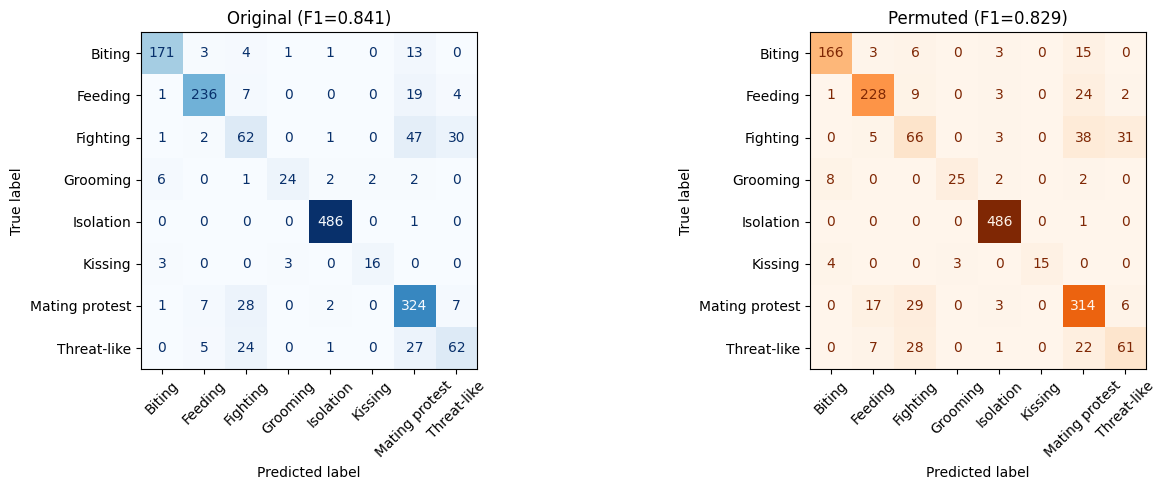

In [19]:
# Confusion matrices
labels_order = sorted(set(y))
disp_labels = [CONTEXT_DICT[c] for c in labels_order]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_o = confusion_matrix(y_test, y_pred_orig, labels=labels_order)
ConfusionMatrixDisplay(cm_o, display_labels=disp_labels).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Original (F1={f1_orig:.3f})')
axes[0].tick_params(axis='x', rotation=45)
cm_p = confusion_matrix(y_perm_test, y_pred_perm, labels=labels_order)
ConfusionMatrixDisplay(cm_p, display_labels=disp_labels).plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title(f'Permuted (F1={f1_perm:.3f})')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()


## 13. HP2 — Wilcoxon rank-sum across contexts


=== HP2: pairwise Wilcoxon p-values ===


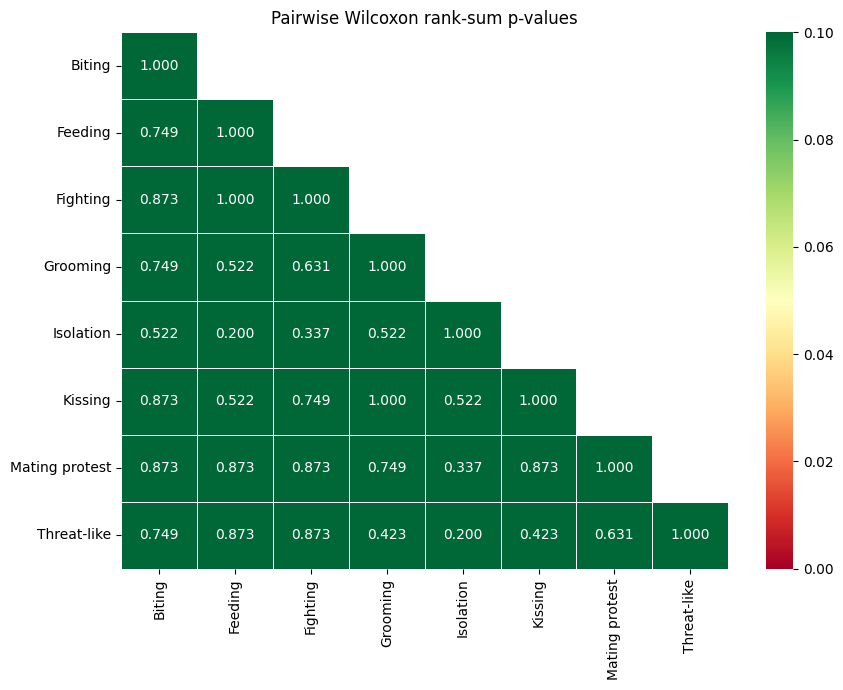


Significant pairs (p<0.05): 0 / 28


In [20]:
ctx_names = [CONTEXT_DICT[c] for c in HP1_CONTEXTS_KEEP if c in set(y)]
ctx_freq = {}
for cn in ctx_names:
    seqs = SEQUENCES[SEQUENCES['context_name'] == cn][ALPHABET]
    if len(seqs) == 0:
        continue
    flat = [s for seq in seqs for s in seq]
    cnts = Counter(flat)
    total = sum(cnts.values())
    syl_types = sorted(set(seg_df['syllable_id']))
    ctx_freq[cn] = np.array([cnts.get(t, 0) / total if total else 0 for t in syl_types])

pval = pd.DataFrame(1.0, index=list(ctx_freq), columns=list(ctx_freq))
for c1, c2 in combinations(ctx_freq, 2):
    stat, p = ranksums(ctx_freq[c1], ctx_freq[c2])
    pval.loc[c1, c2] = p
    pval.loc[c2, c1] = p

print('=== HP2: pairwise Wilcoxon p-values ===')
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(pval, dtype=bool), k=1)
sns.heatmap(pval.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=0.1, mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Pairwise Wilcoxon rank-sum p-values')
plt.tight_layout(); plt.show()

sig = [(c1, c2, pval.loc[c1, c2]) for c1, c2 in combinations(ctx_freq, 2)
       if pval.loc[c1, c2] < 0.05]
print(f'\nSignificant pairs (p<0.05): {len(sig)} / {len(list(combinations(ctx_freq, 2)))}')
for c1, c2, p in sig:
    print(f'  {c1:14s} vs {c2:14s} : p={p:.4f}')


## 14. Diagnostics

Expected paper values (Fig. 1b / Results):

- **7 HDBSCAN clusters** after coarse-graining (Silhouette > 0.5)
- **Mean ARI ≈ 0.12**, **Mean NMI ≈ 0.30** with DTW-MFCC qt_ward proxy
  (n.b. this notebook doesn't build the qt_ward proxy; ARI/NMI here are
  against behavioural context, which the paper doesn't report directly)
- **HP1 F1 > 0.9** for both original and permuted (multi-class pooled RF)


In [21]:
ctx_enc    = LabelEncoder().fit_transform(seg_df['context_name'].values)
noise_frac = float((hdbscan_labels == -1).mean())
ari_ctx = adjusted_rand_score(ctx_enc, hdb_nca_labels)
nmi_ctx = normalized_mutual_info_score(ctx_enc, hdb_nca_labels)

print(f'--- Diagnostics ---')
print(f'Specimens included:       {seg_df["emitter"].nunique()}')
print(f'Segments:                 {len(seg_df)}')
print(f'HDBSCAN clusters (raw):   {n_clusters}     [paper: 7]')
print(f'Noise fraction (pre-NCA): {noise_frac:.1%}')
print(f'N sequences (HP1):        {len(SEQUENCES)}')
print(f'HP1 F1 orig / perm:       {f1_orig:.3f} / {f1_perm:.3f}     [paper: > 0.9 / > 0.9]')

print(f'\n-- ARI/NMI: HDBSCAN vs BEHAVIOURAL CONTEXT (not paper-reported) --')
print(f'ARI(context, syllable):   {ari_ctx:.3f}')
print(f'NMI(context, syllable):   {nmi_ctx:.3f}')

if qt_df is not None:
    print(f'\n-- ARI/NMI: HDBSCAN vs qt_ward PROXY (paper metric) --')
    print(f'Syllable types / emitter (proxy): {qt_df["n_proxy_types"].mean():.1f} ± {qt_df["n_proxy_types"].std():.1f}   [paper: 27 ± 2]')
    print(f'Mean ARI: {qt_df["ari"].mean():.3f} ± {qt_df["ari"].std():.3f}   [paper: 0.12 ± 0.01]')
    print(f'Mean NMI: {qt_df["nmi"].mean():.3f} ± {qt_df["nmi"].std():.3f}   [paper: 0.30 ± 0.01]')


--- Diagnostics ---
Specimens included:       41
Segments:                 53455
HDBSCAN clusters (raw):   6     [paper: 7]
Noise fraction (pre-NCA): 27.6%
N sequences (HP1):        6545
HP1 F1 orig / perm:       0.841 / 0.829     [paper: > 0.9 / > 0.9]

-- ARI/NMI: HDBSCAN vs BEHAVIOURAL CONTEXT (not paper-reported) --
ARI(context, syllable):   0.231
NMI(context, syllable):   0.266

-- ARI/NMI: HDBSCAN vs qt_ward PROXY (paper metric) --
Syllable types / emitter (proxy): 22.7 ± 3.6   [paper: 27 ± 2]
Mean ARI: 0.117 ± 0.050   [paper: 0.12 ± 0.01]
Mean NMI: 0.408 ± 0.091   [paper: 0.30 ± 0.01]


## What's still not paper-faithful (known gaps)

1. **HDBSCAN hyperparameters.** The paper does not list them. We use
   `min_cluster_size = 0.02·N, min_samples=20, epsilon=0.1, method='leaf'`
   from the reference repo. If you don't hit 7 clusters, try
   `min_cluster_size ∈ {0.03, 0.05}·N`.

2. **qt_ward proxy labels.** Paper's ARI/NMI are vs DTW-MFCC agglomerative
   labels (27 ± 2 types per emitter), not vs context. Not implemented here.

3. **RF hyperparameters.** Paper doesn't publish them; `n_estimators=500`
   with `class_weight='balanced'` is a safe default.

4. **Random-Forest feature column order matches Table 1 (a–r); sklearn treats
   columns order-independently**, so this is cosmetic.

5. The paper says 152,578 data points from all 41 bats; the full run here
   should land in that ballpark if `MAX_BATS=None` and the segmentation
   doesn't drop too aggressively.


## Appendix. Save state for ablation studies

Dumps everything the `ablation_per_context_repertoire.ipynb` notebook needs
into one pickle, so the ablation can run without re-doing mel/UMAP/HDBSCAN.


In [22]:
import joblib
_state_path = CHECKPOINT_DIR / 'ablation_state.joblib'
joblib.dump({
    'seg_df':          seg_df,
    'tf_specs':        tf_specs,
    'embedding':       embedding,
    'hdbscan_labels':  hdbscan_labels,
    'hdb_nca_labels':  hdb_nca_labels,
    'SEQUENCES':       SEQUENCES,
    'CONTEXT_DICT':    CONTEXT_DICT,
    'HP1_CONTEXTS_KEEP': HP1_CONTEXTS_KEEP,
    'HDBSCAN_MIN_SAMPLES': HDBSCAN_MIN_SAMPLES,
    'HDBSCAN_EPSILON': HDBSCAN_EPSILON,
    'HDBSCAN_METHOD':  HDBSCAN_METHOD,
    'UMAP_N_NEIGHBORS': UMAP_N_NEIGHBORS,
    'UMAP_MIN_DIST':   UMAP_MIN_DIST,
    'UMAP_METRIC':     UMAP_METRIC,
    'UMAP_SEED':       UMAP_SEED,
    'RANDOM_STATE':    RANDOM_STATE,
}, _state_path, compress=3)
print(f'Saved ablation state to {_state_path}  ({_state_path.stat().st_size // (1024*1024)} MB)')


Saved ablation state to /Volumes/T7/cache/assom_paper_repro/ablation_state.joblib  (245 MB)
